# Tornando visual
Esses códigos abaixo fornecem uma estimativa visual em tempo real de como estão acontecendo as mudanças de pesos e bias para que as ativações dos neurônios sejam feitas e tragam o resultado esperado.


Animação salva como 'neuron_weights_animation.gif'.


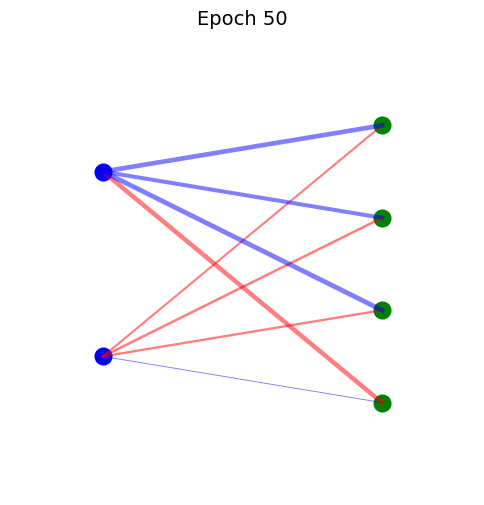

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Gerar dados sintéticos
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Criar modelo simples
model = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='tanh', name='hidden'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Callback para salvar pesos
class WeightHistory(Callback):
    def __init__(self):
        self.weights = []

    def on_epoch_end(self, epoch, logs=None):
        w = self.model.get_layer('hidden').get_weights()[0]
        self.weights.append(w.copy())

weight_history = WeightHistory()

# 4. Treinar modelo
model.fit(X_train, y_train, epochs=50, verbose=0, callbacks=[weight_history])

# 5. Criar animação com neurônios e conexões
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Posições dos neurônios
input_positions = [(2, 3), (2, 7)]  # 2 neurônios de entrada
hidden_positions = [(8, 2), (8, 4), (8, 6), (8, 8)]  # 4 neurônios ocultos

# Desenhar neurônios
for x, y in input_positions:
    ax.plot(x, y, 'o', color='blue', markersize=12)
for x, y in hidden_positions:
    ax.plot(x, y, 'o', color='green', markersize=12)

# Inicializar conexões
lines = []
for i_pos in input_positions:
    for h_pos in hidden_positions:
        line, = ax.plot([i_pos[0], h_pos[0]], [i_pos[1], h_pos[1]], color='gray', alpha=0.5)
        lines.append(line)

# Função de atualização da animação
def update(frame):
    weights = weight_history.weights[frame]
    ax.set_title(f"Epoch {frame+1}", fontsize=14)
    for i in range(2):  # entrada
        for j in range(4):  # oculto
            weight = weights[i][j]
            idx = i * 4 + j
            lines[idx].set_linewidth(abs(weight) * 5)
            lines[idx].set_color('red' if weight > 0 else 'blue')
    return lines

# Criar animação
ani = animation.FuncAnimation(fig, update, frames=len(weight_history.weights),
                              blit=True, repeat=False)

# Salvar como GIF
ani.save("neuron_weights_animation.gif", writer='pillow', fps=5)
print("Animação salva como 'neuron_weights_animation.gif'.")


# Dividindo uma imagem!
Aqui nós vamos dividir uma imagem e entender como ela é de forma digital, ou seja, como ela é representada em forma de matriz.

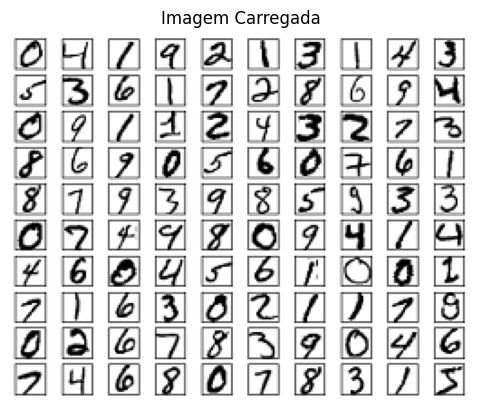

Matriz de pixels da imagem:
[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 ...

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

url = "https://www.deeplearningbook.com.br/wp-content/uploads/2017/12/mnist_100_digits.png"

# Fazer o download da imagem
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Converter a imagem para matriz NumPy
img_array = np.array(img)

# Exibir a imagem
plt.imshow(img_array)
plt.axis('off')
plt.title('Imagem Carregada')
plt.show()

# Exibir a matriz de pixels
print("Matriz de pixels da imagem:")
print(img_array)


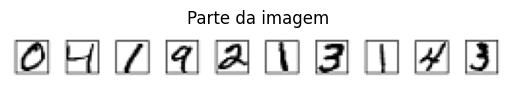

In [65]:
part_img = img_array[0:100][0:23]
plt.imshow(part_img)
plt.axis('off')
plt.title('Parte da imagem')
plt.show()

# Neurônios

In [67]:
import numpy as np

def neuron(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

inputs = np.array([1.0, 2.0])
weights = np.array([0.5, -1.5])
bias = 0.1

output = neuron(inputs, weights, bias)
print("Output:", output)

Output: -2.4


In [68]:
import numpy as np

class SimpleNeuron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = self.sigmoid(np.dot(inputs, self.weights) + self.bias)
        return self.output

    def backward(self, target):
        error = target - self.output
        delta = error * self.sigmoid_derivative(self.output)
        self.weights += self.learning_rate * delta * self.inputs
        self.bias += self.learning_rate * delta
        return error

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            total_error = 0
            for inputs, target in zip(X, y):
                self.forward(inputs)
                error = self.backward(target)
                total_error += error**2
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Error: {total_error:.4f}")


In [69]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])  # Saídas esperadas para OR lógico

In [79]:
SimpleNeuron(2).train(X, y)

Epoch 0, Error: 0.8362
Epoch 100, Error: 0.7163
Epoch 200, Error: 0.5333
Epoch 300, Error: 0.3780
Epoch 400, Error: 0.2784
Epoch 500, Error: 0.2144
Epoch 600, Error: 0.1713
Epoch 700, Error: 0.1409
Epoch 800, Error: 0.1186
Epoch 900, Error: 0.1018


# Images

In [80]:
from torchvision import datasets

mnist = datasets.MNIST(root='./data', train=True, download=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.79MB/s]


In [137]:
print("Tamanho dos dados de treino:", len(mnist.train_data))
print("Shape:", mnist.train_data[0].shape)
print("Tipo:", type(mnist.train_data[0]), "\n")

Tamanho dos dados de treino: 60000
Shape: torch.Size([28, 28])
Tipo: <class 'torch.Tensor'> 



In [92]:
mnist.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [130]:
mnist.data[0].shape

torch.Size([28, 28])

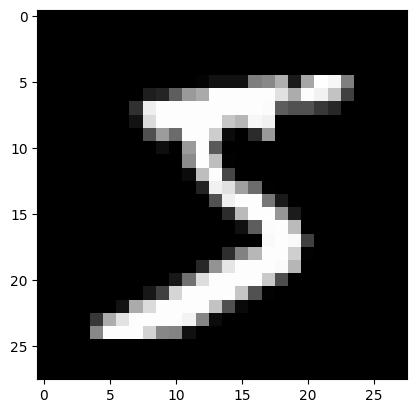

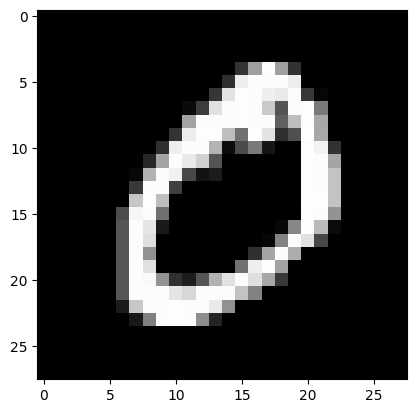

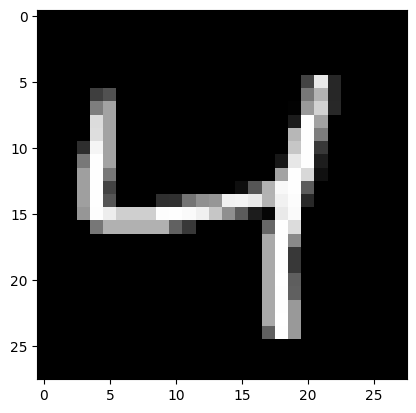

In [134]:
for i in range(3):
  plt.imshow(mnist.data[i],cmap='gray')
  plt.show()

# Reconhecendo digitos

In [187]:
# vamos criar uma classe de rede
# sizes é um vetor que contém o tamanho das redes neurais em cada camada. ex: [2, 5, 6, 1]
class Network(object):
    def __init__(self,sizes):
      self.num_layers = len(sizes)
      self.sizes = sizes
      self.biases = [np.random.randn(y,1) for y in sizes[1:]]
      self.weights = [np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]

    def sigmoid(self,z):
      return 1.0/(1.0+np.exp(-z))

    def feedforward(self,a):
      for b,w in zip(self.biases,self.weights):
        a = self.sigmoid(np.dot(w,a)+b)
      return a

In [186]:
# exemplo de uso
rede1 = Network([2,3,1])
print("W:",rede1.weights)
print("B:",rede1.biases)

W: [array([[-2.34826164, -1.61781174],
       [ 0.10101206,  0.37212388],
       [ 0.49753476, -2.07306668]]), array([[ 2.04535203, -0.22733369,  0.11212944]])]
B: [array([[-1.08158287],
       [-0.96505965],
       [ 0.03529364]]), array([[-0.19333981]])]


# faces

In [160]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()

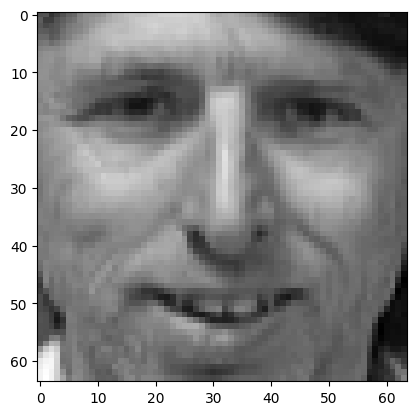

In [179]:
plt.imshow(faces.images[388], cmap="gray")
plt.show()